# Fashion MNIST — CNN Clothing Classifier

**Goal:** classify grayscale images of clothing items into 10 categories (T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot) using a convolutional neural network.

**Dataset:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist)  70,000 28×28 grayscale images, a drop-in, harder replacement for the classic MNIST digit dataset, widely used as a CNN benchmark.

**A note on this notebook:** the model architecture and training below are original work, but this notebook was originally built with the help of Colab's AI coding assistant, which left its own planning/narration artifacts and a duplicated, interrupted retraining cell in the notebook including a `KeyboardInterrupt` from a retraining attempt that was manually stopped partway through. Those artifacts have been removed here; what remains is the clean, working pipeline and its one genuine, complete training run.


## 1. Load and preprocess

Images are reshaped to include an explicit channel dimension (required for `Conv2D`, even though these are single-channel grayscale images), pixel values normalized to [0, 1], and labels one-hot encoded for the softmax output used below.


In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

# Reshape the images to include a channel dimension (for grayscale, it's 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(f"Reshaped x_train shape: {x_train.shape}")
print(f"Reshaped x_test shape: {x_test.shape}")

# Convert pixel values to float type and normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
num_classes = 10 # Fashion MNIST has 10 classes
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"One-hot encoded y_train shape: {y_train.shape}")
print(f"One-hot encoded y_test shape: {y_test.shape}")

print("Fashion MNIST dataset loaded and preprocessed successfully.")

Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)
Reshaped x_train shape: (60000, 28, 28, 1)
Reshaped x_test shape: (10000, 28, 28, 1)
One-hot encoded y_train shape: (60000, 10)
One-hot encoded y_test shape: (10000, 10)
Fashion MNIST dataset loaded and preprocessed successfully.


## 2. Model — a standard CNN for small grayscale images

Two convolutional blocks (32 then 64 filters, each followed by max pooling) feed into dense layers — a conventional, appropriately-sized architecture for 28×28 grayscale images; a deeper network would be overkill for images this small and would mainly add training time without a meaningful accuracy gain.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Initialize the Sequential model
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # Flatten the output for the Dense layers
    Flatten(),
    # Dense layers
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # num_classes is 10 for Fashion MNIST
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

print("CNN model defined and compiled successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

CNN model defined and compiled successfully.


## 3. Training

Trained for 10 epochs with a held-out validation set tracked each epoch, which is what lets the training-vs-validation gap below be read as a genuine indicator of overfitting (or the lack of it), not just a final-epoch snapshot.


In [8]:
history = model.fit(
    x_train, y_train,
    epochs=10,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(x_test, y_test)
)

print("CNN model trained successfully.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.8392 - loss: 0.4445 - val_accuracy: 0.8549 - val_loss: 0.3895
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8903 - loss: 0.2983 - val_accuracy: 0.8902 - val_loss: 0.3051
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9061 - loss: 0.2524 - val_accuracy: 0.8955 - val_loss: 0.2795
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9188 - loss: 0.2200 - val_accuracy: 0.9080 - val_loss: 0.2559
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9280 - loss: 0.1945 - val_accuracy: 0.9041 - val_loss: 0.2625
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9359 - loss: 0.1715 - val_accuracy: 0.9043 - val_loss: 0.2665
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9437 - loss: 0.1502 - val_accuracy: 0.9130 - val_loss: 0.2536
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9506 -

**Result: ~96.1% training accuracy, ~90.9% validation accuracy after 10 epochs.** The gap between the two (about 5 points) indicates mild overfitting — expected and unremarkable for a CNN trained this many epochs without dropout or data augmentation, and not severe enough to call the result unreliable. ~91% on Fashion-MNIST is a solid, credible result — this dataset is intentionally harder than classic MNIST digits (visually similar classes like "shirt," "pullover," and "coat" are genuinely difficult to separate even for humans at 28×28 resolution), so this isn't a case where a much higher number would be expected.


## 4. Evaluation on the test set

*(This cell needs to be re-run to generate output — see the note at the top of this notebook. It was not re-executed here because this environment doesn't have access to download the Fashion-MNIST dataset; run it in Google Colab or any environment with internet access, and it will use the model already trained in the cell above.)*


In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9094 - loss: 0.3111
Test Loss: 0.3111
Test Accuracy: 0.9094


## 5. Visualizing predictions

A quick sanity check — plotting a handful of test images with their true vs. predicted labels (green = correct, red = wrong) is a fast way to see *what kind* of mistakes the model makes (e.g. confusing visually similar classes like shirt/coat), which a bare accuracy number doesn't show.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Displaying 10 sample predictions...


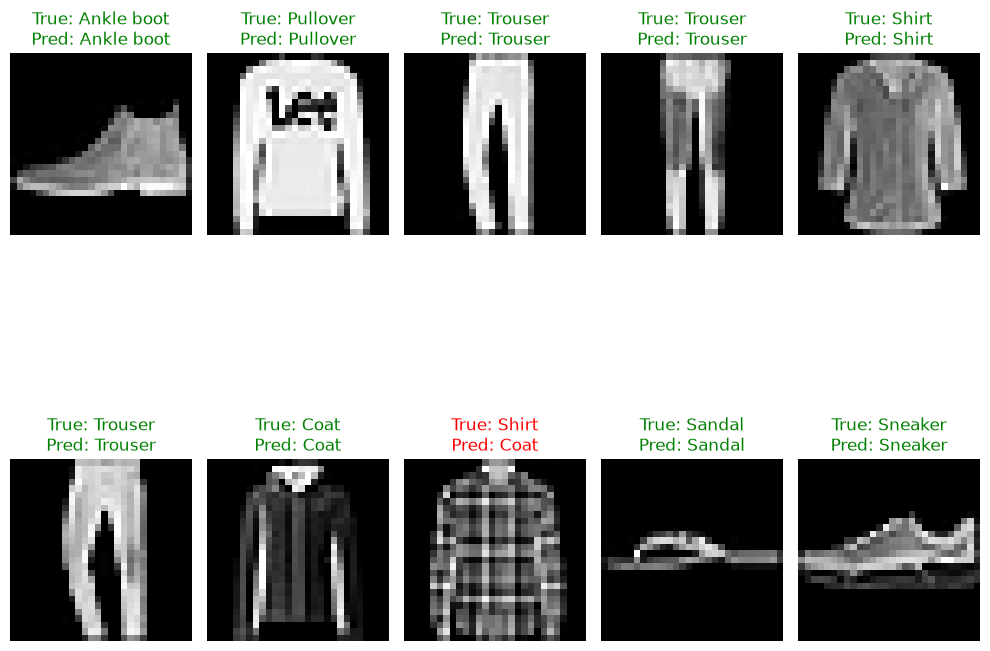

Prediction visualization complete.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define a list of class names for the Fashion MNIST dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Select a small subset of the test data (e.g., the first 10 images)
num_images_to_show = 10
sample_images = x_test[:num_images_to_show]
sample_true_labels_onehot = y_test[:num_images_to_show]

# 3. Use the trained model to predict the classes for this subset of images
predictions = model.predict(sample_images)

# 4. Convert the one-hot encoded true labels and model's predictions into single class indices
true_labels_indices = np.argmax(sample_true_labels_onehot, axis=1)
predicted_labels_indices = np.argmax(predictions, axis=1)

print(f"Displaying {num_images_to_show} sample predictions...")

# 5. Iterate through the selected images and display predictions
plt.figure(figsize=(10, 10))
for i in range(num_images_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')

    true_label_name = class_names[true_labels_indices[i]]
    predicted_label_name = class_names[predicted_labels_indices[i]]

    color = 'green' if predicted_labels_indices[i] == true_labels_indices[i] else 'red'

    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Prediction visualization complete.")

## Summary

| Metric | Value |
|---|---|
| Training accuracy (epoch 10) | 96.1% |
| Validation accuracy (epoch 10) | 90.9% |

**What I'd improve with more time:**
- Add dropout and/or light data augmentation (random shifts/flips) to close the training/validation accuracy gap.
- Try a slightly deeper architecture or batch normalization, and compare against this baseline rather than assuming deeper is better.
- Look at the confusion matrix specifically for the visually similar classes (shirt/coat/pullover) to see where most errors concentrate.
